# Explorative Faktorenanalyse – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/faktorenanalyse)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Die **Faktorenanalyse** (EFA) deckt **latente Strukturen** in großen Variablensätzen auf.
Viele korrelierte Variablen werden auf wenige **Faktoren** (verborgene Variablen) reduziert.

**Wichtige Begriffe:**

| Begriff | Bedeutung |
|---|---|
| **Faktor** | Latente (nicht messbare) Variable, die mehrere beobachtbare Variablen beeinflusst |
| **Faktorladung** | Korrelation zwischen Variable und Faktor (−1 bis +1) |
| **Eigenwert** | Varianz, die ein Faktor erklärt = Summe der quadrierten Ladungen |
| **Kommunalität** | Varianzanteil einer Variable, der durch alle Faktoren erklärt wird |

**Anzahl Faktoren bestimmen:**
- **Kaiser-Kriterium:** Eigenwert > 1
- **Scree-Test:** Knick im Eigenwertplot

**Rotation (Varimax):** Sorgt dafür, dass jede Variable klar auf einen Faktor lädt

**numiqo-Beispiel:** Persönlichkeitseigenschaften → Extraversion, Gewissenhaftigkeit, Verträglichkeit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Persönlichkeitseigenschaften (n=20)

**6 Variablen:** kontaktfreudig, gesellig, arbeitsam, pflichtbewusst, warmherzig, hilfsbereit

**Erwartete Faktoren (numiqo):**
- **Extraversion:** kontaktfreudig + gesellig
- **Gewissenhaftigkeit:** arbeitsam + pflichtbewusst
- **Verträglichkeit:** warmherzig + hilfsbereit

In [2]:
# numiqo-Datensatz simulieren (20 Personen, 6 Items)
np.random.seed(42)
n = 20

# 3 latente Faktoren
extraversion     = np.random.normal(0, 1, n)
gewissenhaft     = np.random.normal(0, 1, n)
vertraeglich     = np.random.normal(0, 1, n)

# 6 beobachtbare Variablen (hohe Ladungen auf jeweiligen Faktor)
noise = 0.4
kontaktfreudig  = 0.85*extraversion  + noise*np.random.normal(0,1,n)
gesellig        = 0.80*extraversion  + noise*np.random.normal(0,1,n)
arbeitsam       = 0.85*gewissenhaft  + noise*np.random.normal(0,1,n)
pflichtbewusst  = 0.80*gewissenhaft  + noise*np.random.normal(0,1,n)
warmherzig      = 0.85*vertraeglich  + noise*np.random.normal(0,1,n)
hilfsbereit     = 0.80*vertraeglich  + noise*np.random.normal(0,1,n)

# Skalieren auf 1-5 (Likert)
def likert(x):
    x = (x - x.min()) / (x.max() - x.min()) * 4 + 1
    return np.round(x, 1)

items = ["kontaktfreudig", "gesellig", "arbeitsam", "pflichtbewusst",
         "warmherzig", "hilfsbereit"]
data_raw = np.column_stack([
    likert(kontaktfreudig), likert(gesellig),
    likert(arbeitsam),      likert(pflichtbewusst),
    likert(warmherzig),     likert(hilfsbereit)
])
df = pd.DataFrame(data_raw, columns=items)

print("Datensatz (erste 5 Zeilen)")
print(df.head().round(2).to_string())
print()

# Korrelationsmatrix
korr = df.corr()
print("Korrelationsmatrix")
print(korr.round(3).to_string())

Datensatz (erste 5 Zeilen)
   kontaktfreudig  gesellig  arbeitsam  pflichtbewusst  warmherzig  hilfsbereit
0             3.9       3.4        4.0             5.0         4.4          3.1
1             3.4       3.1        2.9             2.4         4.3          3.4
2             3.7       4.4        3.2             3.9         2.0          3.3
3             4.5       4.2        1.7             1.0         2.9          2.3
4             3.8       2.4        2.7             2.9         1.4          2.0

Korrelationsmatrix
                kontaktfreudig  gesellig  arbeitsam  pflichtbewusst  warmherzig  hilfsbereit
kontaktfreudig           1.000     0.809     -0.227          -0.088      -0.572       -0.392
gesellig                 0.809     1.000     -0.184          -0.121      -0.558       -0.312
arbeitsam               -0.227    -0.184      1.000           0.814       0.160        0.095
pflichtbewusst          -0.088    -0.121      0.814           1.000       0.101        0.000
warmherz

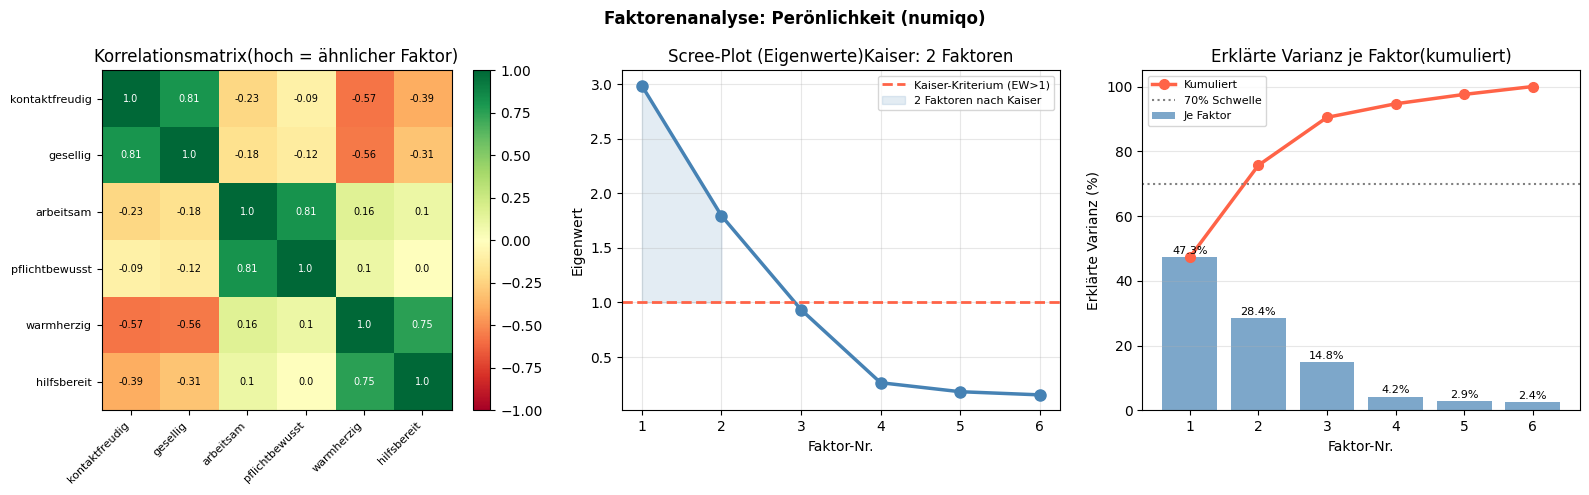

Eigenwerte und erklärte Varianz
Faktor  Eigenwert  Var(%)  Kum(%)
1       2.985      47.3    47.3 <- Kaiser
2       1.794      28.4    75.7 <- Kaiser
3       0.935      14.8    90.5
4       0.265      4.2    94.7
5       0.183      2.9    97.6
6       0.154      2.4    100.0


In [3]:
# PCA als Grundlage der Faktorenanalyse
X_sc = StandardScaler().fit_transform(df)
pca  = PCA()
pca.fit(X_sc)
eigenwerte = pca.explained_variance_

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Faktorenanalyse: Perönlichkeit (numiqo)", fontsize=12,
             fontweight="bold")

# 1. Korrelationsmatrix als Heatmap
im = axes[0].imshow(korr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks(range(6))
axes[0].set_yticks(range(6))
axes[0].set_xticklabels(items, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(items, fontsize=8)
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, str(round(korr.values[i,j], 2)),
                     ha="center", va="center", fontsize=7,
                     color="black" if abs(korr.values[i,j]) < 0.7 else "white")
axes[0].set_title("Korrelationsmatrix(hoch = ähnlicher Faktor)")

# 2. Scree-Plot (Eigenwerte)
k_range = range(1, len(eigenwerte)+1)
axes[1].plot(list(k_range), eigenwerte, "o-", color="steelblue",
             linewidth=2.5, markersize=8)
axes[1].axhline(1, color="tomato", linestyle="--", linewidth=2,
                label="Kaiser-Kriterium (EW>1)")
# Kaiser: Anzahl EW > 1
n_kaiser = (eigenwerte > 1).sum()
axes[1].fill_between(range(1, n_kaiser+1), eigenwerte[:n_kaiser], 1,
                     alpha=0.15, color="steelblue",
                     label=str(n_kaiser) + " Faktoren nach Kaiser")
axes[1].set_title("Scree-Plot (Eigenwerte)Kaiser: " + str(n_kaiser) + " Faktoren")
axes[1].set_xlabel("Faktor-Nr.")
axes[1].set_ylabel("Eigenwert")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. Erklärte Varianz kumuliert
var_kum = np.cumsum(pca.explained_variance_ratio_) * 100
axes[2].bar(list(k_range), pca.explained_variance_ratio_*100,
            color="steelblue", alpha=0.7, label="Je Faktor")
axes[2].plot(list(k_range), var_kum, "o-", color="tomato",
             linewidth=2.5, markersize=7, label="Kumuliert")
axes[2].axhline(70, color="gray", linestyle=":", linewidth=1.5,
                label="70% Schwelle")
axes[2].set_title("Erklärte Varianz je Faktor(kumuliert)")
axes[2].set_xlabel("Faktor-Nr.")
axes[2].set_ylabel("Erklärte Varianz (%)")
axes[2].legend(fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
for k, v in zip(k_range, pca.explained_variance_ratio_*100):
    axes[2].text(k, v+1, str(round(v,1))+"%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

print("Eigenwerte und erklärte Varianz")
print("Faktor  Eigenwert  Var(%)  Kum(%)")
for i, (ew, ev, kum) in enumerate(zip(
    eigenwerte, pca.explained_variance_ratio_*100, var_kum
), 1):
    kaiser = " <- Kaiser" if ew > 1 else ""
    print(str(i) + "       " + str(round(ew,3)) + "      " +
          str(round(ev,1)) + "    " + str(round(kum,1)) + kaiser)

## 2. Faktorladungen und Varimax-Rotation

**Ohne Rotation:** Erster Faktor dominiert – schwer interpretierbar.
**Mit Varimax-Rotation:** Klare Zuordnung – jede Variable lädt hoch auf *einen* Faktor.

Rotierte Faktorladungsmatrix (Varimax)

Variable          F1(Extrav.)  F2(Gewiss.)  F3(Vertr.)  Kommunalitaet

kontaktfreudig  -0.673  **  0.0      -0.02      0.453
gesellig  -0.713  **  0.004      0.052      0.511
arbeitsam  0.031      0.698  **  0.017      0.489
pflichtbewusst  -0.033      0.715  **  -0.02      0.513
warmherzig  0.164      0.023      0.613  **  0.403
hilfsbereit  -0.099      -0.014      0.788  **  0.631

** = höchste Ladung (Faktor-Zuordnung)

Interpretation:
  F1: kontaktfreudig + gesellig      -> Extraversion
  F2: arbeitsam + pflichtbewusst     -> Gewissenhaftigkeit
  F3: warmherzig + hilfsbereit       -> Verträglickeit


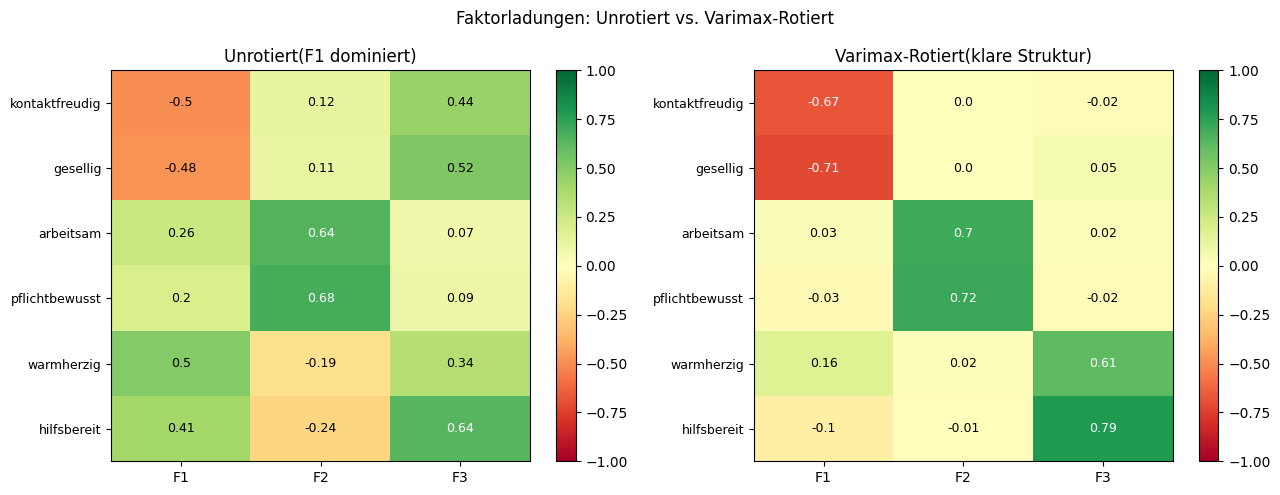

In [5]:
# 3-Faktor-Lösung (PCA + Varimax-Rotation)
pca3 = PCA(n_components=3)
scores = pca3.fit_transform(X_sc)
loadings_unrot = pca3.components_.T  # unrotiert

# Varimax-Rotation manuell
def varimax(loadings, tol=1e-6, max_iter=1000):
    p, k = loadings.shape
    rotation = np.eye(k)
    for _ in range(max_iter):
        old = rotation.copy()
        for i in range(k):
            for j in range(i+1, k):
                L = loadings @ rotation
                u = L[:, i]**2 - L[:, j]**2
                v = 2 * L[:, i] * L[:, j]
                A = u.sum()
                B = v.sum()
                C = (u**2 - v**2).sum()
                D = 2*(u*v).sum()
                num = D - 2*A*B/p
                den = C - (A**2 - B**2)/p
                theta = np.arctan2(num, den) / 4
                rot2x2 = np.array([[np.cos(theta), -np.sin(theta)],
                                   [np.sin(theta),  np.cos(theta)]])
                rotation[:, [i,j]] = rotation[:, [i,j]] @ rot2x2
        if np.max(np.abs(rotation - old)) < tol:
            break
    return loadings @ rotation

loadings_rot = varimax(loadings_unrot)

# Kommunalitäten
kommunalitaeten = (loadings_rot**2).sum(axis=1)

print("Rotierte Faktorladungsmatrix (Varimax)")
print()
header = "Variable          F1(Extrav.)  F2(Gewiss.)  F3(Vertr.)  Kommunalitaet"
print(header)
print()
for i, item in enumerate(items):
    l1, l2, l3 = loadings_rot[i]
    k_val = kommunalitaeten[i]
    # Höchste Ladung markieren
    max_l = max(abs(l1), abs(l2), abs(l3))
    mark = lambda x: "  **" if abs(x) == max_l else "    "
    print(item + "  " + str(round(l1,3)) + mark(l1) +
          "  " + str(round(l2,3)) + mark(l2) +
          "  " + str(round(l3,3)) + mark(l3) +
          "  " + str(round(k_val,3)))
print()
print("** = höchste Ladung (Faktor-Zuordnung)")
print()
print("Interpretation:")
print("  F1: kontaktfreudig + gesellig      -> Extraversion")
print("  F2: arbeitsam + pflichtbewusst     -> Gewissenhaftigkeit")
print("  F3: warmherzig + hilfsbereit       -> Verträglickeit")

# Visualisierung: Ladungsmatrix als Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Faktorladungen: Unrotiert vs. Varimax-Rotiert", fontsize=12)

for ax, ladungen, titel in [
    (axes[0], loadings_unrot, "Unrotiert(F1 dominiert)"),
    (axes[1], loadings_rot,   "Varimax-Rotiert(klare Struktur)")
]:
    im = ax.imshow(ladungen, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(6))
    ax.set_xticklabels(["F1", "F2", "F3"])
    ax.set_yticklabels(items, fontsize=9)
    ax.set_title(titel)
    for i in range(6):
        for j in range(3):
            ax.text(j, i, str(round(ladungen[i,j], 2)),
                    ha="center", va="center", fontsize=9,
                    color="white" if abs(ladungen[i,j]) > 0.6 else "black")

plt.tight_layout()
plt.show()

## 3. Zusammenfassung

```
Explorative Faktorenanalyse (EFA) – Übersicht
│
├── WAS?
│   Dimensionsreduktion: viele Variablen -> wenige Faktoren
│   Latente (nicht messbare) Strukturen aufdecken
│
├── ABLAUF
│   1. Korrelationsmatrix berechnen
│   2. Eigenwertproblem lösen (PCA als Grundlage)
│   3. Anzahl Faktoren bestimmen
│      Kaiser: Eigenwert > 1
│      Scree-Test: Knick im Eigenwertplot
│   4. Faktorladungsmatrix berechnen
│   5. Rotation (Varimax) für klare Struktur
│   6. Faktoren inhaltlich interpretieren
│
├── WICHTIGE KENNWERTE
│   Faktorladung:  Korrelation Variable-Faktor
│                  > 0.5 = gute Ladung
│   Eigenwert:     Erklärte Varianz eines Faktors
│   Kommunalität: Erklärte Varianz einer Variable
│
├── numiqo-BEISPIEL: Persönlichkeit (n=20)
│   6 Items -> 3 Faktoren nach Kaiser
│   F1: kontaktfreudig, gesellig    (Extraversion)
│   F2: arbeitsam, pflichtbewusst   (Gewissenhaftigkeit)
│   F3: warmherzig, hilfsbereit     (Verträglichkeit)
│
└── PYTHON
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    X_sc = StandardScaler().fit_transform(X)
    pca  = PCA(n_components=k)
    pca.fit(X_sc)
    eigenwerte = pca.explained_variance_
    ladungen   = pca.components_.T
    # + Varimax-Rotation (manuell oder via factor_analyzer)
```

---
Quelle: [numiqo.de/tutorial/faktorenanalyse](https://numiqo.de/tutorial/faktorenanalyse)